# Secretary Problem — Markov Chain Simulations

**Anton Björk, Samuel Jonsson and Rafael Proença**

This notebook contains all simulations for the Secretary Problem project.
We use three approaches to compute $p_W(t^*)$, the probability of selecting the best item:

1. **Matrix power method** (exact): Build the transition matrix $\mathbf{P}$, compute $\boldsymbol{\pi}^{(t^*+1)} = \boldsymbol{\pi}^{(0)} \mathbf{P}^{t^*+1}$, extract $p_W$.
2. **Markov chain simulation**: Sample transitions from $\mathbf{P}$ step-by-step until absorption.
3. **Direct simulation**: Generate random permutations and apply the stopping rule.

All three methods agree, validating that the Markov chain correctly models the secretary problem.

## Shared Utilities

Core functions used by all cells: transition matrix construction, matrix power method,
direct simulation, and Markov chain step-by-step simulation.

In [21]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

output_dir = Path.cwd() / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)


# ── Build transition matrix (Eq. 8 in Simon) ───────────────────────

def build_transition_matrix(n, t_star):
    """
    Build the (n+2) x (n+2) stochastic matrix P.

    States indexed 0..n+1:
        0..n-1  ->  candidate arrival times 1..n
        n       ->  W (win / hire best)
        n+1     ->  L (lose / hire non-best)

    Transition probabilities:
      Absorbing:    p_{W,W} = 1,  p_{L,L} = 1
      Observation:  p_{t,t'} = t / [t'(t'-1)],  p_{t,L} = t/n
      Selection:    p_{t,W}  = t/n,              p_{t,L} = 1 - t/n
    """
    size = n + 2
    W, L = n, n + 1
    P = np.zeros((size, size))

    P[W, W] = 1.0
    P[L, L] = 1.0

    for t_idx in range(n):
        t = t_idx + 1
        if t <= t_star:
            for tp_idx in range(t_idx + 1, n):
                tp = tp_idx + 1
                P[t_idx, tp_idx] = t / (tp * (tp - 1))
            P[t_idx, L] = t / n
        else:
            P[t_idx, W] = t / n
            P[t_idx, L] = 1.0 - t / n

    return P


# ── Compute p_W via matrix powers ───────────────────────────────────

def win_probability_matrix(n, t_star):
    """Compute p_W(t*) = [pi^(0) @ P^{t*+1}]_W"""
    P = build_transition_matrix(n, t_star)
    pi_0 = np.zeros(n + 2)
    pi_0[0] = 1.0
    P_power = np.linalg.matrix_power(P, t_star + 1)
    return (pi_0 @ P_power)[n]


# ── Direct Monte Carlo simulation ───────────────────────────────────

def simulate_direct(n, t_star, num_trials=100_000):
    """
    Generate random permutations and apply the stopping rule.
    No knowledge of the Markov chain — pure baseline.
    """
    wins = 0
    for _ in range(num_trials):
        perm = np.random.permutation(n)  # 0 = best
        if t_star == 0:
            best_seen = np.inf
        else:
            best_seen = perm[:t_star].min()

        selected = None
        for t in range(t_star, n):
            if perm[t] < best_seen:
                selected = perm[t]
                break
            best_seen = min(best_seen, perm[t])

        if selected is None:
            selected = perm[-1]

        if selected == 0:
            wins += 1

    return wins / num_trials


# ── Markov chain step-by-step simulation ────────────────────────────

def simulate_markov_chain(n, t_star, num_trials=100_000):
    """
    Start at T_0 = 1, sample transitions from P one step at a time
    until absorption into W or L.
    """
    P = build_transition_matrix(n, t_star)
    W, L = n, n + 1
    states = np.arange(n + 2)

    wins = 0
    for _ in range(num_trials):
        current = 0  # T_0 = 1 (index 0)
        while current != W and current != L:
            current = np.random.choice(states, p=P[current, :])
        if current == W:
            wins += 1

    return wins / num_trials


# ── Exhaustive search for optimal stopping rule ──────────────────────

def find_optimal_stopping_rule(n):
    """t*_opt = argmax_{t* in [0..n-1]} p_W(t*)"""
    t_star_values = np.arange(0, n)
    pw_values = [win_probability_matrix(n, t) for t in t_star_values]
    t_opt = t_star_values[np.argmax(pw_values)]
    p_opt = max(pw_values)
    return t_opt, p_opt, t_star_values, pw_values

## Figure 1: Transition Matrix Heatmap

Visualisation of $\mathbf{P}$ for $n=5$, $t^*=2$. States 1–2 are in the observation phase,
states 3–5 in the selection phase, and $W$, $L$ are absorbing.

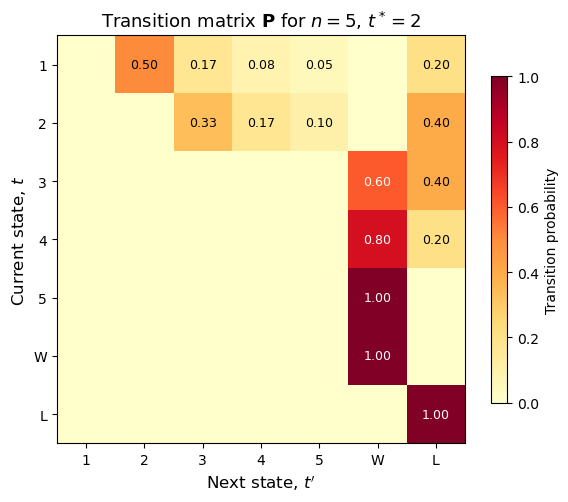

Row sums of P: [1. 1. 1. 1. 1. 1. 1.]


In [22]:
n_ex, t_star_ex = 5, 2
P_ex = build_transition_matrix(n_ex, t_star_ex)

fig1, ax1 = plt.subplots(figsize=(6, 5))
labels = [str(i) for i in range(1, n_ex + 1)] + ["W", "L"]

im = ax1.imshow(P_ex, cmap="YlOrRd", vmin=0, vmax=1)
ax1.set_xticks(range(n_ex + 2))
ax1.set_xticklabels(labels)
ax1.set_yticks(range(n_ex + 2))
ax1.set_yticklabels(labels)
ax1.set_xlabel("Next state, $t'$", fontsize=12)
ax1.set_ylabel("Current state, $t$", fontsize=12)
ax1.set_title(f"Transition matrix $\\mathbf{{P}}$ for $n={n_ex}$, $t^*={t_star_ex}$", fontsize=13)

for i in range(n_ex + 2):
    for j in range(n_ex + 2):
        val = P_ex[i, j]
        if val > 0.005:
            color = "white" if val > 0.5 else "black"
            ax1.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=9, color=color)

plt.colorbar(im, ax=ax1, label="Transition probability", shrink=0.8)
plt.tight_layout()
plt.savefig(output_dir / "transition_matrix.pdf", bbox_inches="tight")
plt.show()

print(f"Row sums of P: {P_ex.sum(axis=1)}")

## Figure 2: State Probability Evolution

Evolution of $\boldsymbol{\pi}^{(i)}$ for $n=5$, $t^*=2$. At $i = t^*+1 = 3$,
all probability mass has been absorbed into $W$ and $L$.

## Figure 1b: Transition Matrix Heatmap for $n=10$

Visualisation of $\mathbf{P}$ for $n=10$, $t^*=3$ (optimal). States 1–3 are in the observation phase,
states 4–10 in the selection phase, and $W$, $L$ are absorbing.

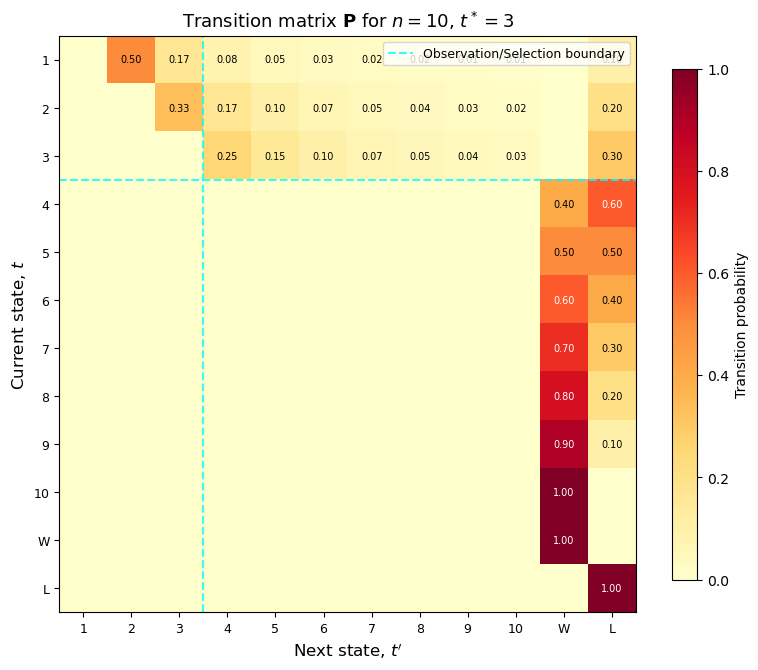

Row sums of P (n=10): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [23]:
n_ex_10, t_star_ex_10 = 10, 3
P_ex_10 = build_transition_matrix(n_ex_10, t_star_ex_10)

fig1b, ax1b = plt.subplots(figsize=(8, 7))
labels_10 = [str(i) for i in range(1, n_ex_10 + 1)] + ["W", "L"]

im_10 = ax1b.imshow(P_ex_10, cmap="YlOrRd", vmin=0, vmax=1)
ax1b.set_xticks(range(n_ex_10 + 2))
ax1b.set_xticklabels(labels_10, fontsize=9)
ax1b.set_yticks(range(n_ex_10 + 2))
ax1b.set_yticklabels(labels_10, fontsize=9)
ax1b.set_xlabel("Next state, $t'$", fontsize=12)
ax1b.set_ylabel("Current state, $t$", fontsize=12)
ax1b.set_title(f"Transition matrix $\\mathbf{{P}}$ for $n={n_ex_10}$, $t^*={t_star_ex_10}$", fontsize=13)

# Mark observation/selection boundary
ax1b.axhline(t_star_ex_10 - 0.5, color="cyan", linewidth=1.5, linestyle="--", alpha=0.8, label="Observation/Selection boundary")
ax1b.axvline(t_star_ex_10 - 0.5, color="cyan", linewidth=1.5, linestyle="--", alpha=0.8)

# Annotate some key cells to avoid clutter
for i in range(n_ex_10 + 2):
    for j in range(n_ex_10 + 2):
        val = P_ex_10[i, j]
        if val > 0.01:
            color = "white" if val > 0.5 else "black"
            ax1b.text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=7, color=color)

plt.colorbar(im_10, ax=ax1b, label="Transition probability", shrink=0.8)
ax1b.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(output_dir / "transition_matrix_n10.pdf", bbox_inches="tight")
plt.show()

print(f"Row sums of P (n=10): {P_ex_10.sum(axis=1)}")

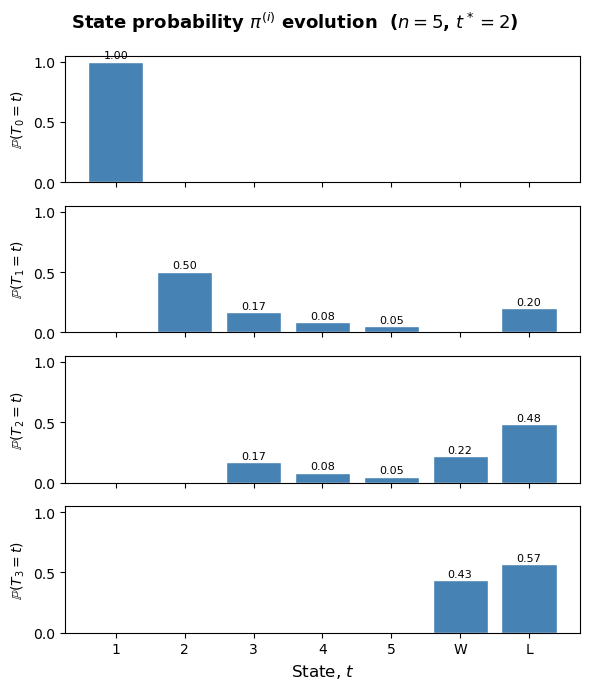

In [24]:
fig2, axes2 = plt.subplots(t_star_ex + 2, 1, figsize=(6, 7), sharex=True)
fig2.suptitle(
    f"State probability $\\pi^{{(i)}}$ evolution  ($n={n_ex}$, $t^*={t_star_ex}$)",
    fontsize=13, fontweight="bold",
)

labels = [str(i) for i in range(1, n_ex + 1)] + ["W", "L"]
pi = np.zeros(n_ex + 2)
pi[0] = 1.0

for i, ax in enumerate(axes2):
    ax.bar(range(n_ex + 2), pi, color="steelblue", edgecolor="white")
    ax.set_ylabel(f"$\\mathbb{{P}}(T_{i}=t)$", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.5, 1.0])
    for idx, val in enumerate(pi):
        if val > 0.01:
            ax.text(idx, val + 0.03, f"{val:.2f}", ha="center", fontsize=8)
    pi = pi @ P_ex

axes2[-1].set_xticks(range(n_ex + 2))
axes2[-1].set_xticklabels(labels)
axes2[-1].set_xlabel("State, $t$", fontsize=12)

plt.tight_layout()
plt.savefig(output_dir / "state_evolution.pdf", bbox_inches="tight")
plt.show()

## Figure 3: $p_W(t^*)$ via Matrix Powers vs Monte Carlo

The blue curve is the **exact** result from $\boldsymbol{\pi}^{(0)} \mathbf{P}^{t^*+1}$.
Red dots are Monte Carlo estimates for validation.

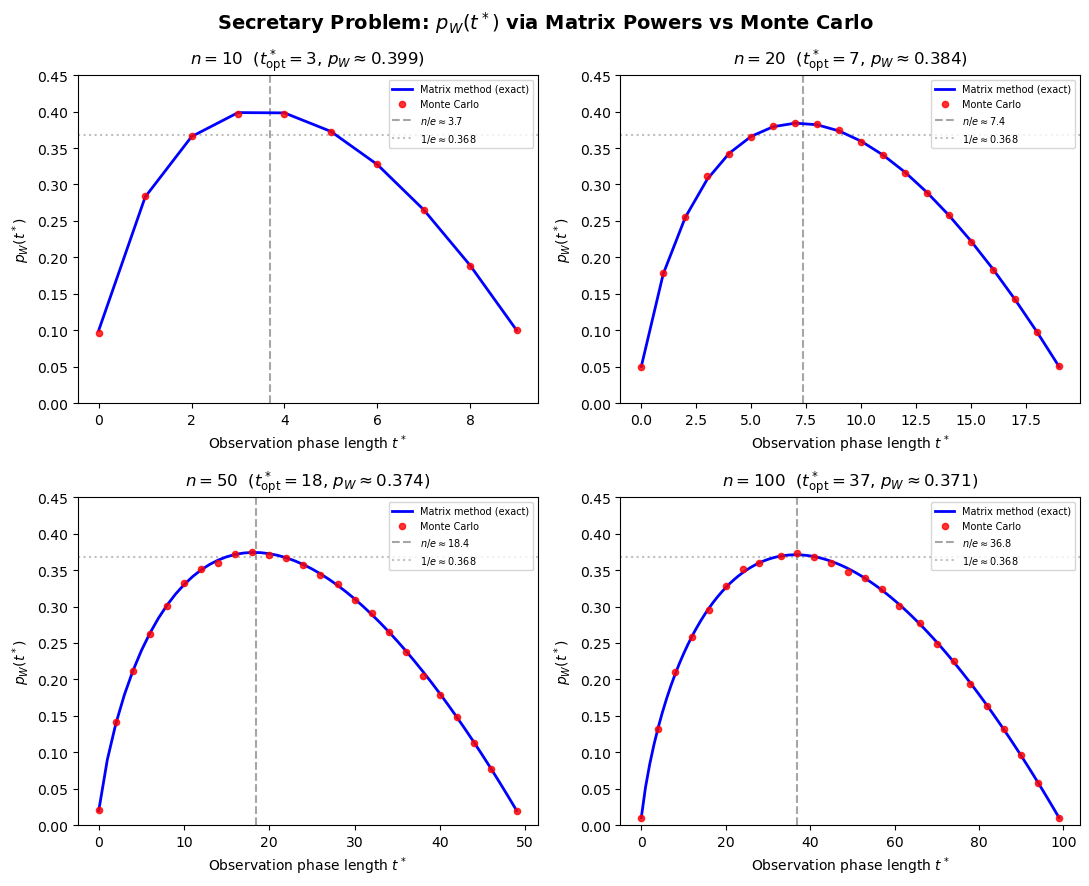


Convergence of optimal stopping rule to n/e and 1/e
     n  t*_opt  floor(n/e)  p_W(t*_opt)       1/e
-------------------------------------------------------
     5       2           1      0.43333   0.36788
    10       3           3      0.39869   0.36788
    20       7           7      0.38421   0.36788
    50      18          18      0.37428   0.36788
   100      37          36      0.37104   0.36788


In [25]:
n_values = [10, 20, 50, 100]
num_trials = 50_000

fig3, axes3 = plt.subplots(2, 2, figsize=(11, 9))
fig3.suptitle(
    "Secretary Problem: $p_W(t^*)$ via Matrix Powers vs Monte Carlo",
    fontsize=14, fontweight="bold",
)

for ax, n in zip(axes3.flat, n_values):
    t_stars = np.arange(0, n)
    pw_matrix = [win_probability_matrix(n, t) for t in t_stars]

    if n <= 20:
        mc_ts = t_stars
    else:
        mc_ts = np.linspace(0, n - 1, min(n, 25), dtype=int)
    pw_mc = [simulate_direct(n, t, num_trials) for t in mc_ts]

    t_opt = np.argmax(pw_matrix)
    p_opt = pw_matrix[t_opt]

    ax.plot(t_stars, pw_matrix, "b-", linewidth=2,
            label="Matrix method (exact)", zorder=3)
    ax.scatter(mc_ts, pw_mc, color="red", s=20, marker="o",
               zorder=5, label="Monte Carlo", alpha=0.8)
    ax.axvline(n / np.e, color="gray", linestyle="--", alpha=0.7,
               label=f"$n/e \\approx {n / np.e:.1f}$")
    ax.axhline(1 / np.e, color="gray", linestyle=":", alpha=0.5,
               label=f"$1/e \\approx {1 / np.e:.3f}$")

    ax.set_title(f"$n = {n}$  ($t^*_{{\\mathrm{{opt}}}} = {t_opt}$,"
                 f" $p_W \\approx {p_opt:.3f}$)")
    ax.set_xlabel("Observation phase length $t^*$")
    ax.set_ylabel("$p_W(t^*)$")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_ylim(0, 0.45)

plt.tight_layout()
plt.savefig(output_dir / "pw_vs_tstar.pdf", bbox_inches="tight")
plt.show()

# ── Convergence table ──
print("\nConvergence of optimal stopping rule to n/e and 1/e")
print(f"{'n':>6}  {'t*_opt':>6}  {'floor(n/e)':>10}  {'p_W(t*_opt)':>11}  {'1/e':>8}")
print("-" * 55)
for n in [5, 10, 20, 50, 100]:
    pw = [win_probability_matrix(n, t) for t in range(n)]
    t_opt = np.argmax(pw)
    p_opt = pw[t_opt]
    print(f"{n:>6}  {t_opt:>6}  {int(n / np.e):>10}  {p_opt:>11.5f}  {1 / np.e:>8.5f}")

    

## Figure 4: Three-Way Validation

All three methods — matrix powers (exact), Markov chain simulation (sampling from $\mathbf{P}$),
and direct simulation (random permutations) — produce identical results,
confirming that the transition matrix $\mathbf{P}$ correctly models the secretary problem.

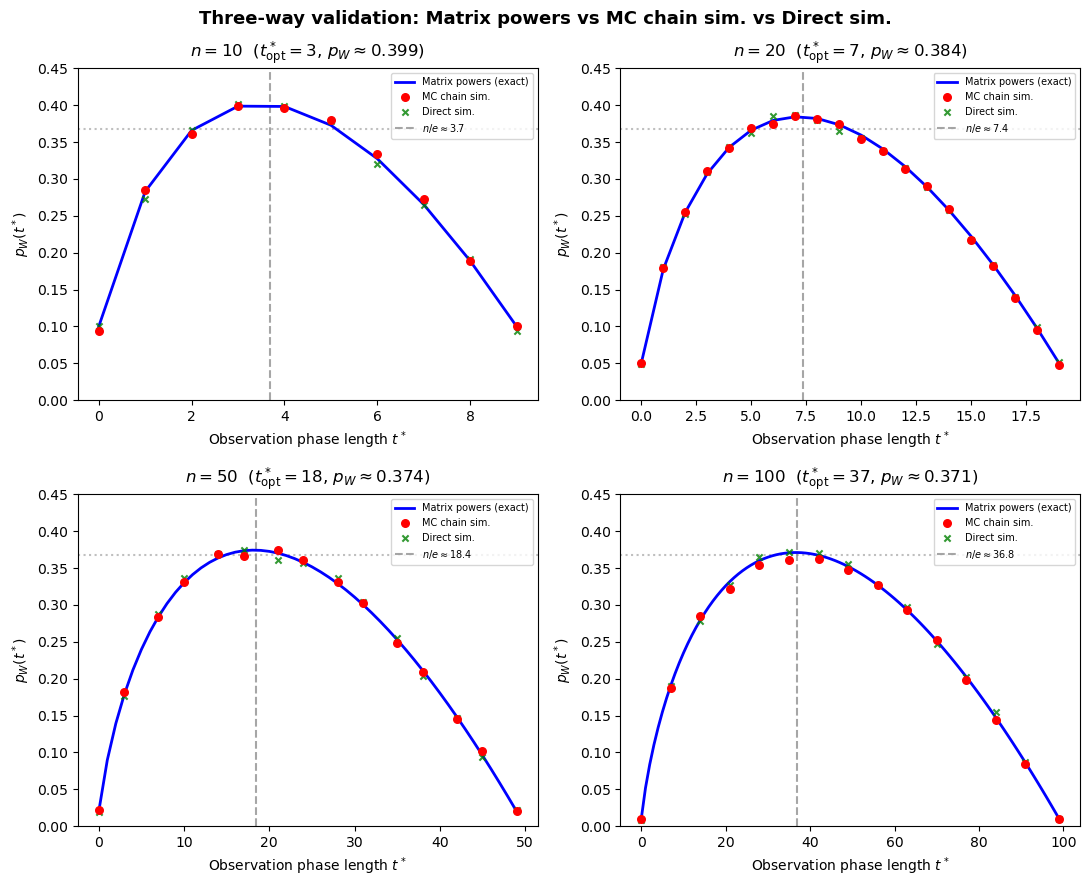


Comparison for n=10:
  t*  Matrix (exact)  MC chain sim    Direct sim
--------------------------------------------------
   0         0.10000       0.09950       0.10300
   1         0.28290       0.28780       0.28080
   2         0.36579       0.36650       0.36670
   3         0.39869       0.40360       0.40020
   4         0.39825       0.39640       0.39260
   5         0.37282       0.37710       0.37260
   6         0.32738       0.32800       0.33780
   7         0.26528       0.26460       0.26220
   8         0.18889       0.18730       0.19670
   9         0.10000       0.09990       0.09850


In [26]:
n_values = [10, 20, 50, 100]
num_trials = 10_000

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle(
    "Three-way validation: Matrix powers vs MC chain sim. vs Direct sim.",
    fontsize=13, fontweight="bold",
)

for ax, n in zip(axes.flat, n_values):
    t_stars = np.arange(0, n)
    pw_exact = [win_probability_matrix(n, t) for t in t_stars]

    if n <= 20:
        sim_ts = t_stars
    else:
        sim_ts = np.unique(np.linspace(0, n - 1, min(n, 15), dtype=int))

    pw_mc = [simulate_markov_chain(n, t, num_trials) for t in sim_ts]
    pw_direct = [simulate_direct(n, t, num_trials) for t in sim_ts]

    t_opt = np.argmax(pw_exact)
    p_opt = pw_exact[t_opt]

    ax.plot(t_stars, pw_exact, "b-", linewidth=2,
            label="Matrix powers (exact)", zorder=3)
    ax.scatter(sim_ts, pw_mc, color="red", s=30, marker="o",
               zorder=5, label="MC chain sim.")
    ax.scatter(sim_ts, pw_direct, color="green", s=20, marker="x",
               zorder=4, label="Direct sim.", alpha=0.8)
    ax.axvline(n / np.e, color="gray", linestyle="--", alpha=0.7,
               label=f"$n/e \\approx {n / np.e:.1f}$")
    ax.axhline(1 / np.e, color="gray", linestyle=":", alpha=0.5)

    ax.set_title(f"$n = {n}$  ($t^*_{{\\mathrm{{opt}}}} = {t_opt}$,"
                 f" $p_W \\approx {p_opt:.3f}$)")
    ax.set_xlabel("Observation phase length $t^*$")
    ax.set_ylabel("$p_W(t^*)$")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_ylim(0, 0.45)

plt.tight_layout()
plt.savefig(output_dir / "three_way_validation.pdf", bbox_inches="tight")
plt.show()

# ── Comparison table for n=10 ──
print("\nComparison for n=10:")
print(f"{'t*':>4}  {'Matrix (exact)':>14}  {'MC chain sim':>12}  {'Direct sim':>12}")
print("-" * 50)
for t in range(10):
    exact = win_probability_matrix(10, t)
    mc = simulate_markov_chain(10, t, 10_000)
    direct = simulate_direct(10, t, 10_000)
    print(f"{t:>4}  {exact:>14.5f}  {mc:>12.5f}  {direct:>12.5f}")

## Figure 5: Optimal Stopping Rule via Exhaustive Search

Following Simon's Eq. 14: $t^*_{\mathrm{opt}} = \arg\max_{t^* \in [0..n-1]} p_W(t^*)$.
We compute $p_W(t^*)$ for every possible $t^*$ and pick the maximum.

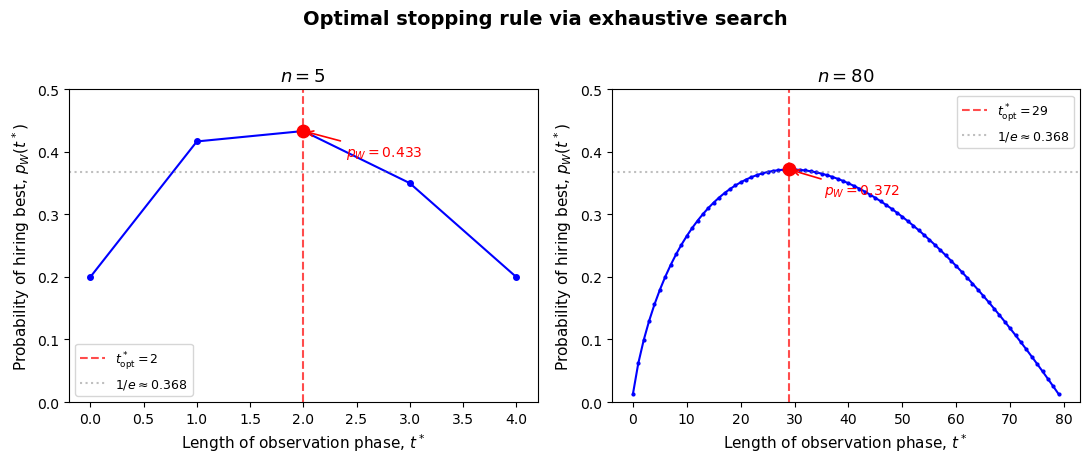

Exhaustive search: optimal stopping rule for various n
     n  t*_opt  floor(n/e)  p_W(t*_opt)       1/e
----------------------------------------------------------
     3       1           1      0.50000   0.36788
     4       1           1      0.45833   0.36788
     5       2           1      0.43333   0.36788
    10       3           3      0.39869   0.36788
    20       7           7      0.38421   0.36788
    50      18          18      0.37428   0.36788
    80      29          29      0.37186   0.36788
   100      37          36      0.37104   0.36788

Full exhaustive search for n = 5:
-----------------------------------
  t* = 0:  p_W = 0.20000
  t* = 1:  p_W = 0.41667
  t* = 2:  p_W = 0.43333  <-- optimal
  t* = 3:  p_W = 0.35000
  t* = 4:  p_W = 0.20000


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, n in zip(axes, [5, 80]):
    t_opt, p_opt, t_stars, pw = find_optimal_stopping_rule(n)

    ax.plot(t_stars, pw, "b.-", linewidth=1.5, markersize=4 if n > 20 else 8)
    ax.axvline(t_opt, color="red", linestyle="--", alpha=0.7,
               label=f"$t^*_{{\\mathrm{{opt}}}} = {t_opt}$")
    ax.axhline(1 / np.e, color="gray", linestyle=":", alpha=0.5,
               label=f"$1/e \\approx {1/np.e:.3f}$")

    ax.scatter([t_opt], [p_opt], color="red", s=80, zorder=5)
    ax.annotate(
        f"$p_W = {p_opt:.3f}$",
        xy=(t_opt, p_opt),
        xytext=(t_opt + n * 0.08, p_opt - 0.04),
        fontsize=10, color="red",
        arrowprops=dict(arrowstyle="->", color="red", lw=1.2),
    )

    ax.set_xlabel("Length of observation phase, $t^*$", fontsize=11)
    ax.set_ylabel("Probability of hiring best, $p_W(t^*)$", fontsize=11)
    ax.set_title(f"$n = {n}$", fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 0.5)

fig.suptitle(
    "Optimal stopping rule via exhaustive search",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(output_dir / "optimal_stopping.pdf", bbox_inches="tight")
plt.show()

# ── Exhaustive search table ──
print("Exhaustive search: optimal stopping rule for various n")
print(f"{'n':>6}  {'t*_opt':>6}  {'floor(n/e)':>10}  {'p_W(t*_opt)':>11}  {'1/e':>8}")
print("-" * 58)
for n in [3, 4, 5, 10, 20, 50, 80, 100]:
    t_opt, p_opt, _, _ = find_optimal_stopping_rule(n)
    print(f"{n:>6}  {t_opt:>6}  {int(n / np.e):>10}  {p_opt:>11.5f}  {1/np.e:>8.5f}")

# ── Full search for n=5 ──
print("\nFull exhaustive search for n = 5:")
print("-" * 35)
t_opt, p_opt, t_stars, pw = find_optimal_stopping_rule(5)
for t, p in zip(t_stars, pw):
    marker = "  <-- optimal" if t == t_opt else ""
    print(f"  t* = {t}:  p_W = {p:.5f}{marker}")

## Additional Analysis Plots

The following plots extend the report with summary diagnostics across $n$ and $t^*$.

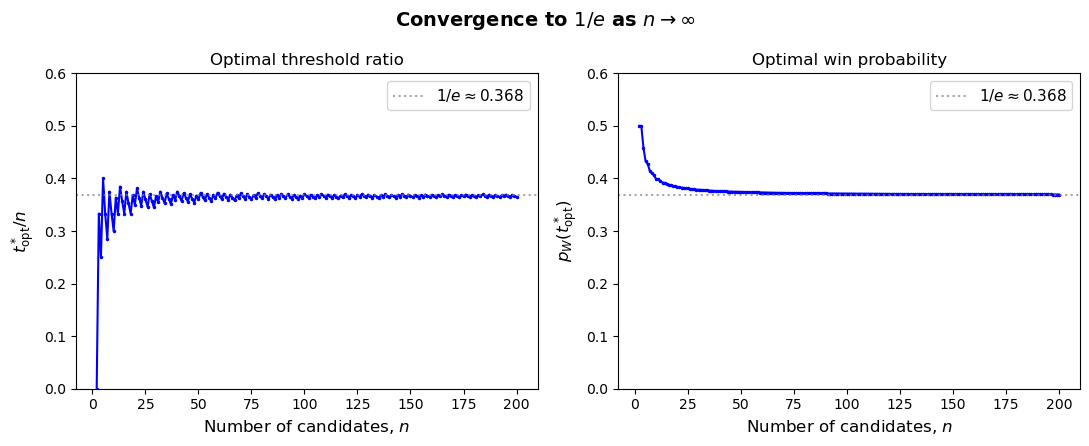

In [28]:
## Figure: Convergence of t*_opt/n and p_W(t*_opt) to 1/e as n → ∞

n_values = list(range(2, 201))

t_opt_ratios = []
p_opt_values = []

for n in n_values:
    t_opt, p_opt, _, _ = find_optimal_stopping_rule(n)
    t_opt_ratios.append(t_opt / n)
    p_opt_values.append(p_opt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Convergence to $1/e$ as $n \\to \\infty$", fontsize=14, fontweight="bold")

# Left: t*_opt / n → 1/e
ax1.plot(n_values, t_opt_ratios, "b.-", linewidth=1.5, markersize=3)
ax1.axhline(1 / np.e, color="gray", linestyle=":", alpha=0.7, label=f"$1/e \\approx {1/np.e:.3f}$")
ax1.set_xlabel("Number of candidates, $n$", fontsize=12)
ax1.set_ylabel("$t^*_{\\mathrm{opt}} / n$", fontsize=12)
ax1.set_title("Optimal threshold ratio", fontsize=12)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 0.6)

# Right: p_W(t*_opt) → 1/e
ax2.plot(n_values, p_opt_values, "b.-", linewidth=1.5, markersize=3)
ax2.axhline(1 / np.e, color="gray", linestyle=":", alpha=0.7, label=f"$1/e \\approx {1/np.e:.3f}$")
ax2.set_xlabel("Number of candidates, $n$", fontsize=12)
ax2.set_ylabel("$p_W(t^*_{\\mathrm{opt}})$", fontsize=12)
ax2.set_title("Optimal win probability", fontsize=12)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 0.6)

plt.tight_layout()
plt.savefig(output_dir / "convergence_to_1_over_e.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure: Win probability heatmap over $n$ and $t^*/n$

This summarizes how the success probability changes across problem size and stopping threshold.

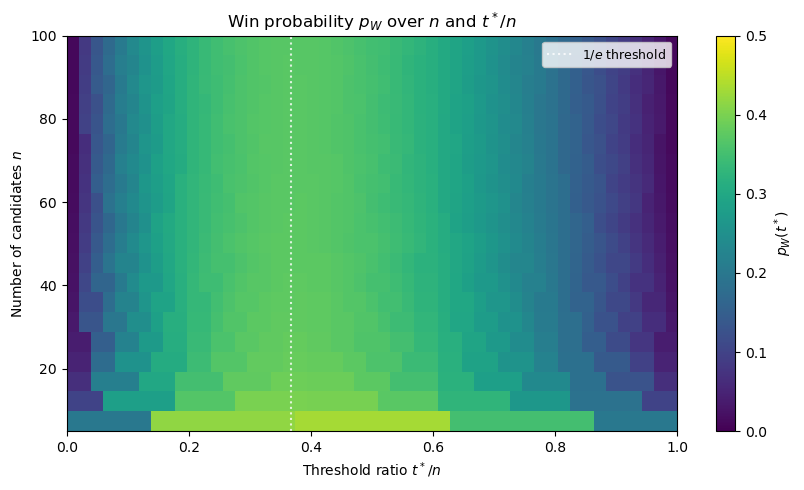

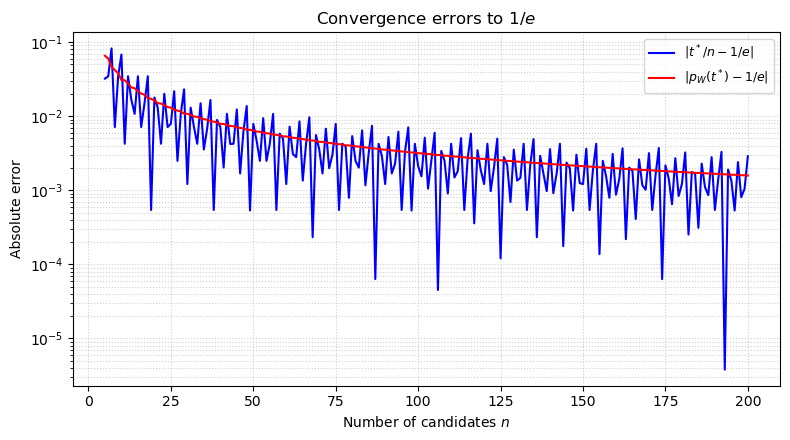

In [29]:
# Heatmap of p_W across n and t*/n
n_grid = list(range(5, 101, 5))
ratio_grid = np.linspace(0, 1, 51)

pw_heatmap = np.zeros((len(n_grid), len(ratio_grid)))

for i, n in enumerate(n_grid):
    for j, r in enumerate(ratio_grid):
        t_star = int(np.round(r * (n - 1)))
        t_star = max(0, min(n - 1, t_star))
        pw_heatmap[i, j] = win_probability_matrix(n, t_star)

fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(
    pw_heatmap,
    aspect="auto",
    origin="lower",
    extent=[ratio_grid.min(), ratio_grid.max(), n_grid[0], n_grid[-1]],
    cmap="viridis",
    vmin=0,
    vmax=0.5,
    interpolation="nearest",
)

ax.axvline(1 / np.e, color="white", linestyle=":", linewidth=1.5, alpha=0.8, label=r"$1/e$ threshold")
ax.set_xlabel(r"Threshold ratio $t^*/n$")
ax.set_ylabel(r"Number of candidates $n$")
ax.set_title(r"Win probability $p_W$ over $n$ and $t^*/n$")
ax.legend(loc="upper right", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$p_W(t^*)$")

plt.tight_layout()
plt.savefig(output_dir / "pw_heatmap_over_n_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Convergence errors vs n ──
n_values = list(range(5, 201))
t_ratio_err = []
p_opt_err = []

for n in n_values:
    t_opt, p_opt, _, _ = find_optimal_stopping_rule(n)
    t_ratio_err.append(abs(t_opt / n - 1 / np.e))
    p_opt_err.append(abs(p_opt - 1 / np.e))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_values, t_ratio_err, "b-", label=r"$|t^*/n - 1/e|$")
ax.plot(n_values, p_opt_err, "r-", label=r"$|p_W(t^*) - 1/e|$")
ax.set_xlabel(r"Number of candidates $n$")
ax.set_ylabel("Absolute error")
ax.set_title("Convergence errors to $1/e$")
ax.set_yscale("log")
ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / "convergence_errors_log.png", dpi=150, bbox_inches="tight")
plt.show()

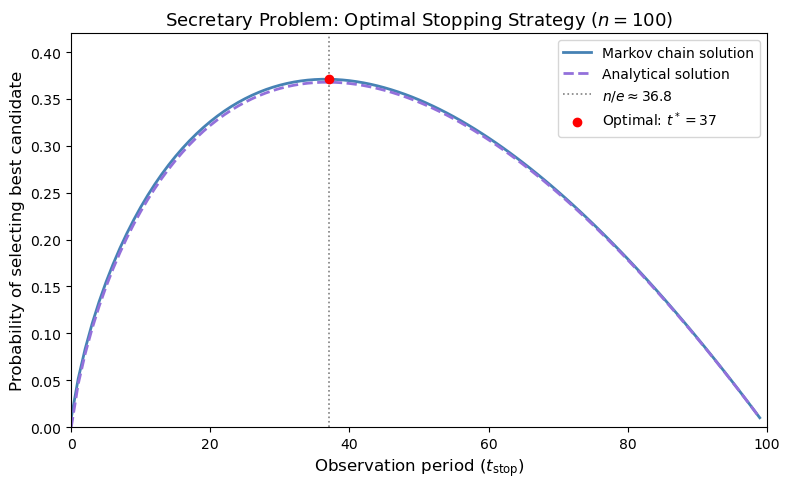

In [31]:
## Figure 1: Secretary Problem — Markov chain vs Analytical solution (n=100)

n = 100
t_stars = np.arange(0, n)

# Markov chain (exact)
pw_mc = [win_probability_matrix(n, t) for t in t_stars]

# Analytical approximation: p_W(t*) ≈ (t*/n) * ln(n/t*)
pw_analytical = [(t / n) * np.log(n / t) if t > 0 else 0 for t in t_stars]

t_opt, p_opt, _, _ = find_optimal_stopping_rule(n)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_stars, pw_mc, color="steelblue", linewidth=2, label="Markov chain solution")
ax.plot(t_stars, pw_analytical, color="mediumpurple", linewidth=2,
        linestyle="--", label="Analytical solution")
ax.axvline(t_opt, color="gray", linestyle=":", linewidth=1.2,
           label=f"$n/e \\approx {n/np.e:.1f}$")
ax.scatter([t_opt], [p_opt], color="red", zorder=5,
           label=f"Optimal: $t^* = {t_opt}$")

ax.set_xlabel("Observation period ($t_\\mathrm{stop}$)", fontsize=12)
ax.set_ylabel("Probability of selecting best candidate", fontsize=12)
ax.set_title(f"Secretary Problem: Optimal Stopping Strategy ($n = {n}$)", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, n)
ax.set_ylim(0, 0.42)

plt.tight_layout()
plt.savefig(output_dir / "secretary_problem_fig1.pdf", bbox_inches="tight")
plt.show()

## Export plots for submission

This cell verifies expected plot files and bundles them into a single ZIP for easy download.

In [30]:
from pathlib import Path
import zipfile

output_dir = Path.cwd() / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

expected_files = [
    "transition_matrix.pdf",
    "transition_matrix_n10.pdf",
    "state_evolution.pdf",
    "pw_vs_tstar.pdf",
    "three_way_validation.pdf",
    "optimal_stopping.pdf",
    "convergence_to_1_over_e.png",
    "pw_heatmap_over_n_ratio.png",
    "convergence_errors_log.png",
]

missing = [name for name in expected_files if not (output_dir / name).exists()]
if missing:
    print("Missing plot files:")
    for name in missing:
        print(f"  - {name}")
    print("Run the plotting cells above to regenerate missing files.")
else:
    print("All expected plot files are present.")

zip_path = output_dir / "submission_plots.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for name in expected_files:
        file_path = output_dir / name
        if file_path.exists():
            zf.write(file_path, arcname=name)

print(f"Created ZIP: {zip_path}")

All expected plot files are present.
Created ZIP: c:\Users\Rafallex\Documents\Uppsala\year 1\period 3\MP\Project\outputs\submission_plots.zip
